# <center>**Data Analysis of tnfr2, f480** </center>

## **Import the essential libraries** 

In [1]:
from pathlib import Path
from typing import List, Dict
import pandas as pd
from matplotlib import pyplot as plt
import statistics as st
import statsmodels.api as sm
import numpy as np
import random as rd
import os
import seaborn as sns
from sklearn.neighbors import NearestNeighbors
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

## **Setup output format** 

In [2]:
pd.set_option('display.max_columns', 30)
pd.set_option('display.max_rows', 30)

## **Declare the output folder**

In [3]:
result_folder="result2"
os.makedirs(result_folder, exist_ok=True)
result_path=Path.cwd()/result_folder
print(result_path) 

D:\IPPTPAN\Project\Population effect of Macrophase\Manuscript_Data\result2


## **Load input data** 

In [4]:
# load quantifications for p65, relb and cd 36
file_path = "tnfr2_f480.pkl.gz"
quant_df = pd.read_pickle(file_path, compression='gzip')
quant_df['circularity_normalized'] = quant_df['circularity'] / quant_df['nuc_area']**0.2 #Add circularity normalized by area


In [5]:
quant_df

nuc_area  nuc_area_masked  nuc_eccentricity  \
Plate Well Clone nucleus_id                                                
1     0203 -1    1               48.5              0.0             0.297   
                 2               76.5              0.0             0.233   
                 3               24.5              0.0             0.346   
                 4               50.5              0.0             0.052   
                 5               86.5              0.0             0.437   
...                               ...              ...               ...   
4     0705 -1    29747           11.5              0.0             0.231   
                 29748           13.0              0.0             0.390   
                 29749           11.0              0.0             0.211   
                 29750           15.5              0.0             0.106   
                 29751            4.0              0.0             0.172   

                             nuc_is_toggled  nuc_center_x  nuc_center_y  \
Plate Well Clone nucleus_id                                               
1     0203 -1    1                        0       4994.94       9247.49   
                 2                        0       4128.72       9208.09   
                 3                        0       4944.93       9200.32   
                 4                        0       5010.92       9201.34   
                 5                        0       5044.19       9189.13   
...                                     ...           ...           ...   
4     0705 -1    29747                    0       4526.41       3680.28   
                 29748                    0       4748.85       3315.41   
                 29749                    0       6448.00       3241.00   
                 29750                    0       9200.84       1542.62   
                 29751                    0       6937.00       1102.50   

                             nuc_tnfr2_intensity_min  nuc_tnfr2_intensity_max  \
Plate Well Clone nucleus_id                                                     
1     0203 -1    1                                63                       76   
                 2                                18                       21   
                 3                                52                       73   
                 4                                79                      109   
                 5                                71                      106   
...                                              ...                      ...   
4     0705 -1    29747                            11                       70   
                 29748                            72                      113   
                 29749                            71                      130   
                 29750                            34                       41   
                 29751                            65                       80   

                             nuc_tnfr2_intensity_median  \
Plate Well Clone nucleus_id                               
1     0203 -1    1                                   69   
                 2                                   19   
                 3                                   64   
                 4                                   92   
                 5                                   87   
...                                                 ...   
4     0705 -1    29747                               15   
                 29748                               88   
                 29749                              113   
                 29750                               37   
                 29751                               70   

                             nuc_tnfr2_intensity_quartile1  \
Plate Well Clone nucleus_id                                  
1     0203 -1    1                                      68   
                 2                                      

### **Verifing the Data**

In [6]:
quant_df.columns

Index(['nuc_area', 'nuc_area_masked', 'nuc_eccentricity', 'nuc_is_toggled',
       'nuc_center_x', 'nuc_center_y', 'nuc_tnfr2_intensity_min',
       'nuc_tnfr2_intensity_max', 'nuc_tnfr2_intensity_median',
       'nuc_tnfr2_intensity_quartile1',
       ...
       'per_dpc_intensity_h1_mean', 'per_dpc_intensity_h2_mean',
       'per_dpc_intensity_inertia', 'per_dpc_intensity_sum', 'origin',
       'solidity', 'circularity', 'longest_hv_stretch', 'distance_to_corner',
       'circularity_normalized'],
      dtype='object', length=174)

In [7]:
quant_df.index.get_level_values("Well").unique()

Index(['0203', '0204', '0205', '0206', '0207', '0208', '0209', '0210', '0303',
       '0304', '0305', '0306', '0307', '0308', '0309', '0310', '0403', '0404',
       '0405', '0406', '0407', '0408', '0409', '0410', '0503', '0504', '0505',
       '0506', '0507', '0508', '0509', '0510', '0603', '0604', '0605', '0703',
       '0704', '0705'],
      dtype='object', name='Well')

In [8]:
quant_df.shape

(899494, 174)

### **Applying Constrains for Data Cleaning**

In [9]:
TO_UM2 = 0.598**2 # remove nuclei that are too small or too large
MIN_AREA_UM2, MAX_AREA_UM2= 25, 225
quant_df = quant_df[ (MIN_AREA_UM2 <= quant_df["nuc_area"]*TO_UM2) & (quant_df["nuc_area"]*TO_UM2 <= MAX_AREA_UM2) ]
ECC=0.3 # remove nuclei that are not round - eccentricity > 0.3)
quant_df=quant_df[quant_df["nuc_eccentricity"] <ECC]
CN0=0.145 # remove nuclei that are not circular 
quant_df=quant_df[quant_df["circularity_normalized"] > CN0]
HV0=12 # remove nuclei that are flat on one side 
quant_df=quant_df[quant_df["longest_hv_stretch"] <= HV0]
D0=50 # remove nuclei that are close to the edge (in  pixels) 
quant_df=quant_df[quant_df["distance_to_corner"] > D0]
# remove nuclei for which there is no perinuclei
a=len(quant_df)
quant_df = quant_df[quant_df['per_area'] != 0]
print('Removed',a-len(quant_df[quant_df['per_area'] != 0]),'nuclei')
print("Total number of nuclei are removed",a)


Removed 487 nuclei
Total number of nuclei are removed 498769


### **Manually Enumerate Different Treatment Conditions In The Main DataFrame**

In [10]:
# Define a function to assign the 'Lipid A' condition based on the well
def assign_lipid_a_condition(well):
    if well.startswith('02') or well.startswith('04') or well.startswith('06'):
        return 'Mock'
    elif well.startswith('03') or well.startswith('05') or well.startswith('07'):
        return '500 ng/mL'
    else:
        return 'Unknown'  # Optional, for wells not starting with '0' or '03'

def assign_cells_well_condition(well):
    if well.startswith('02') or well.startswith('03'):
        return 20
    elif well.startswith('04') or well.startswith('05'):
        return 500
    elif well.startswith('06') or well.startswith('07'):
        return 10000
    else:
        return 'Unknown'  # Optional, for wells not starting with '0' or '03'

def assign_staining_condition(well):
    if well.startswith('0203') or well.startswith('0303') or well.startswith('0403') or well.startswith('0503') or well.startswith('0603') or well.startswith('0703'):
        return 'No'
    else:
        return 'Yes' 

# Add columns for new conditions
#clones_df = clones_df.reset_index()
quant_df = quant_df.copy()  # Ensure we work with a copy

quant_df.loc[:, 'Lipid A'] = [
    assign_lipid_a_condition(well)
    for well in quant_df.index.get_level_values('Well').astype(str)
]
quant_df.loc[:, 'Cells_well'] = [
    assign_cells_well_condition(well)
    for well in quant_df.index.get_level_values('Well').astype(str)
]

quant_df.loc[:, 'Staining'] = [
    assign_staining_condition(well)
    for well in quant_df.index.get_level_values('Well').astype(str)
]

quant_df

nuc_area  nuc_area_masked  nuc_eccentricity  \
Plate Well Clone nucleus_id                                                
1     0203 -1    2               76.5              0.0             0.233   
                 9              158.5              0.0             0.158   
                 10              92.5              0.0             0.120   
                 11              85.5              0.0             0.060   
                 12              77.0              0.0             0.112   
...                               ...              ...               ...   
4     0705 -1    29640          154.0              0.0             0.206   
                 29641          115.0              0.0             0.146   
                 29652          183.0              0.0             0.085   
                 29656          127.0              0.0             0.194   
                 29658          124.0              0.0             0.067   

                             nuc_is_toggled  nuc_center_x  nuc_center_y  \
Plate Well Clone nucleus_id                                               
1     0203 -1    2                        0       4128.72       9208.09   
                 9                        0       6313.97       9099.38   
                 10                       0       6401.79       9072.19   
                 11                       0       6345.61       9037.91   
                 12                       0       3746.31       8995.21   
...                                     ...           ...           ...   
4     0705 -1    29640                    0       6440.85        403.31   
                 29641                    0       6379.97        410.52   
                 29652                    0       6284.35        320.36   
                 29656                    0       5951.37        302.19   
                 29658                    0       6354.60        286.86   

                             nuc_tnfr2_intensity_min  nuc_tnfr2_intensity_max  \
Plate Well Clone nucleus_id                                                     
1     0203 -1    2                                18                       21   
                 9                                17                       21   
                 10                               18                       21   
                 11                               18                       22   
                 12                               18                       21   
...                                              ...                      ...   
4     0705 -1    29640                            42                      101   
                 29641                            71                      231   
                 29652                            24                       76   
                 29656                            32                      102   
                 29658                            32                      126   

                             nuc_tnfr2_intensity_median  \
Plate Well Clone nucleus_id                               
1     0203 -1    2                                   19   
                 9                                   19   
                 10                                  19   
                 11                                  19   
                 12                                  19   
...                                                 ...   
4     0705 -1    29640                               55   
                 29641                              104   
                 29652                               32   
                 29656                               43   
                 29658                               47   

                             nuc_tnfr2_intensity_quartile1  \
Plate Well Clone nucleus_id                                  
1     0203 -1    2                                      19   
                 9                                      

## **Create a clean Data File**

In [11]:
# quant_df.to_pickle('IFs_36-38--Plate_series1clean.pkl')

In [12]:
quant_df.to_pickle('tnfr2_f480_clean.pkl')

In [13]:
# clean_df_short

## **Experiment settings**

In [14]:
# # Experiment settings
EXPERIMENT_FOLDER = "IF38"  # Main folder containing experiment data
PLATE_FOLDER = "IF38_Plate1A2 "  # Specific subfolder to process
layout_dfs = []

# Path to the specific plate folder
plate_path = Path.cwd()

# Path to WellsInfo.pkl
layout_path = plate_path /'WellsInfo2.pkl'

# Process the specific file if it exists
if layout_path.exists():
    try:
        layout_df = pd.read_pickle(layout_path)
        layout_df.replace('N/A', pd.NA, inplace=True)
        layout_df['Experiment'] = PLATE_FOLDER  # Add folder name as experiment identifier
        layout_df = layout_df.reset_index().set_index(['Experiment', 'Row', 'Column'])
        for integer_col in ['Days_in_culture', 'Cells_well']:
            layout_df[integer_col] = layout_df[integer_col].astype(int)
        layout_dfs.append(layout_df)
    except Exception as e:
        print(f"Error processing file: {layout_path}. Error: {e}")
else:
    print(f"File not found: {layout_path}")

# Combine the DataFrame (only one in this case)
if layout_dfs:
    layout_df = pd.concat(layout_dfs)
layout_df.index

MultiIndex([('IF38_Plate1A2 ', 2,  3),
            ('IF38_Plate1A2 ', 2,  4),
            ('IF38_Plate1A2 ', 2,  5),
            ('IF38_Plate1A2 ', 2,  6),
            ('IF38_Plate1A2 ', 2,  7),
            ('IF38_Plate1A2 ', 2,  8),
            ('IF38_Plate1A2 ', 2,  9),
            ('IF38_Plate1A2 ', 2, 10),
            ('IF38_Plate1A2 ', 3,  3),
            ('IF38_Plate1A2 ', 3,  4),
            ('IF38_Plate1A2 ', 3,  5),
            ('IF38_Plate1A2 ', 3,  6),
            ('IF38_Plate1A2 ', 3,  7),
            ('IF38_Plate1A2 ', 3,  8),
            ('IF38_Plate1A2 ', 3,  9),
            ('IF38_Plate1A2 ', 3, 10),
            ('IF38_Plate1A2 ', 4,  3),
            ('IF38_Plate1A2 ', 4,  4),
            ('IF38_Plate1A2 ', 4,  5),
            ('IF38_Plate1A2 ', 4,  6),
            ('IF38_Plate1A2 ', 4,  7),
            ('IF38_Plate1A2 ', 4,  8),
            ('IF38_Plate1A2 ', 4,  9),
            ('IF38_Plate1A2 ', 4, 10),
            ('IF38_Plate1A2 ', 5,  3),
            ('IF38_Plate1

# Sort data into clones and daughter cells

In [15]:
#Clone cells
clean_df = quant_df.loc[
    (quant_df.index.get_level_values('Clone') >= 0) & (quant_df['Staining'] == 'Yes')
]

# Daughter  cells
clean_df1=quant_df.loc[
    (quant_df['Cells_well'] == 500) & (quant_df['Staining'] == 'Yes')
]

# Density_controls
clean_df2=quant_df.loc[
    (quant_df['Cells_well'] == 10000) & (quant_df['Staining'] == 'Yes')
]

combined_df = pd.concat([clean_df, clean_df1,clean_df2])

In [16]:
# clean_df1.to_pickle('IF36_Plate_series1_mixed_cells.pkl') 

In [17]:
clean_df1.to_pickle('tnfr2_f480_mixed_cells.pkl')

In [18]:
# combined_df.to_pickle('IFs_36-38_plate_series1_clean_cells.pkl')

In [19]:
combined_df.to_pickle('tnfr2_f480_cells.pkl')

In [20]:
a=combined_df.groupby(['Plate','Well','Lipid A','Cells_well']).agg("size").reset_index(name='count')

In [21]:
np.log2(a.query("Plate==1 & `Lipid A`=='Mock' & Cells_well==500")["count"].mean())

np.float64(9.427163163682385)

In [22]:
# clean_df_short = clean_df.reset_index()[["Plate","Lipid A","Day in Culture","nucleus_id","nuc_il1b_intensity_80_mean","per_il1b_intensity_80_mean","nuc_tnfa_intensity_80_mean","per_tnfa_intensity_80_mean"]]

### Export data for manuscript

#### 1. Morphology for mix population

In [23]:
df_mix=combined_df.query("Cells_well==10000 or Cells_well==500")
len(df_mix)

191358

In [24]:

df_morphology_mix=df_mix.reset_index()[["Plate",'Well', "Lipid A","nucleus_id","Cells_well","per_tnfr2_intensity_80_mean","per_f480_intensity_80_mean",'nuc_area','nuc_area_masked','nuc_eccentricity','per_area','solidity','circularity',
                      'longest_hv_stretch','circularity_normalized']]

df_morphology_mix

,Plate,Well,Lipid A,nucleus_id,Cells_well,per_tnfr2_intensity_80_mean,per_f480_intensity_80_mean,nuc_area,nuc_area_masked,nuc_eccentricity,per_area,solidity,circularity,longest_hv_stretch,circularity_normalized
0,1,0404,Mock,1,500,125.466,93.676,79.0,0.0,0.158,96.0,1.0,0.446466,5,0.186321
1,1,0404,Mock,2,500,126.055,90.138,85.5,0.0,0.242,103.5,1.0,0.401455,8,0.164909
2,1,0404,Mock,3,500,149.148,89.148,101.0,0.0,0.123,108.0,1.0,0.482549,6,0.191724
3,1,0404,Mock,4,500,160.643,99.488,86.0,0.0,0.088,100.0,1.0,0.433399,4,0.177823
4,1,0404,Mock,10,500,130.350,89.850,71.0,0.0,0.035,94.5,1.0,0.410675,5,0.175084
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
191353,4,0705,500 ng/mL,29640,10000,79.323,42.519,154.0,0.0,0.206,127.5,1.0,0.528136,9,0.192860
191354,4,0705,500 ng/mL,29641,10000,118.022,73.942,115.0,0.0,0.146,46.5,1.0,0.476220,5,0.184361
191355,4,0705,500 ng/mL,29652,10000,66.150,72.125,183.0,0.0,0.085,145.0,1.0,0.573779,5,0.202420
191356,4,0705,500 ng/mL,29656,10000,56.865,64.775,127.0,0.0,0.194,122.0,1.0,0.508372,6,0.192939


#### 2. Morphology for clonal population

In [25]:
df_morphology_clone=clean_df.reset_index()[["Plate",'Well', "Lipid A","nucleus_id","Cells_well","per_tnfr2_intensity_80_mean","per_f480_intensity_80_mean",'nuc_area','nuc_area_masked','nuc_eccentricity','per_area','solidity','circularity',
                      'longest_hv_stretch','circularity_normalized']]

df_morphology_clone

,Plate,Well,Lipid A,nucleus_id,Cells_well,per_tnfr2_intensity_80_mean,per_f480_intensity_80_mean,nuc_area,nuc_area_masked,nuc_eccentricity,per_area,solidity,circularity,longest_hv_stretch,circularity_normalized
0,1,0204,Mock,144,20,90.923,119.067,123.0,0.0,0.134,125.0,1.0,0.486614,6,0.185868
1,1,0204,Mock,146,20,77.727,91.705,81.5,0.0,0.106,93.0,1.0,0.450528,6,0.186849
2,1,0204,Mock,175,20,94.515,56.530,121.0,0.0,0.080,110.0,1.0,0.536006,7,0.205406
3,1,0204,Mock,176,20,129.241,64.040,96.5,0.0,0.179,106.0,1.0,0.467545,8,0.187464
4,1,0204,Mock,177,20,74.210,45.177,85.0,0.0,0.123,100.5,1.0,0.446466,7,0.183613
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
134629,4,0310,500 ng/mL,1532,20,133.619,95.727,97.0,0.0,0.039,45.0,1.0,0.485608,7,0.194505
134630,4,0310,500 ng/mL,1533,20,138.530,121.360,125.0,0.0,0.072,118.5,1.0,0.547446,4,0.208430
134631,4,0310,500 ng/mL,1534,20,105.431,74.332,98.0,0.0,0.143,110.5,1.0,0.452659,4,0.180936
134632,4,0310,500 ng/mL,1536,20,74.523,82.977,110.5,0.0,0.105,57.5,1.0,0.499812,7,0.195045


## **Display overview of clean data**

In [26]:
plate_clones_df = combined_df.loc[2, :, :, :]
plate_clones_well_ids = plate_clones_df.index.get_level_values('Well').unique().sort_values()
plate_clones_well_ids

Index(['0204', '0205', '0206', '0207', '0208', '0209', '0210', '0304', '0305',
       '0306', '0307', '0308', '0309', '0310', '0404', '0405', '0406', '0407',
       '0408', '0409', '0410', '0504', '0505', '0506', '0507', '0508', '0509',
       '0510', '0604', '0605'],
      dtype='object', name='Well')

In [27]:
# show an overview of clusters
NCOLS = 10  # Columns from 3 to 10
NROWS = 7  # Rows from 2 to 8

fig_mosaic = [[f"{r + 1:02d}{c + 1:02d}" for c in range(2,NCOLS)] for r in range(1,NROWS)]
fig_opts = dict(sharex=True, sharey=True, figsize=(NCOLS*1.5, NROWS*1.5))
scatter_opts = dict(s=0.3, alpha=0.4, edgecolors='none')
annot_opts = dict(xy=(0.5, 0.91), xycoords='axes fraction', ha='center', alpha=0.5)
sides = ('top', 'right', 'left', 'bottom')

unique_plates = combined_df.index.get_level_values("Plate").unique()

In [28]:
fig_mosaic

[['0203', '0204', '0205', '0206', '0207', '0208', '0209', '0210'],
 ['0303', '0304', '0305', '0306', '0307', '0308', '0309', '0310'],
 ['0403', '0404', '0405', '0406', '0407', '0408', '0409', '0410'],
 ['0503', '0504', '0505', '0506', '0507', '0508', '0509', '0510'],
 ['0603', '0604', '0605', '0606', '0607', '0608', '0609', '0610'],
 ['0703', '0704', '0705', '0706', '0707', '0708', '0709', '0710']]

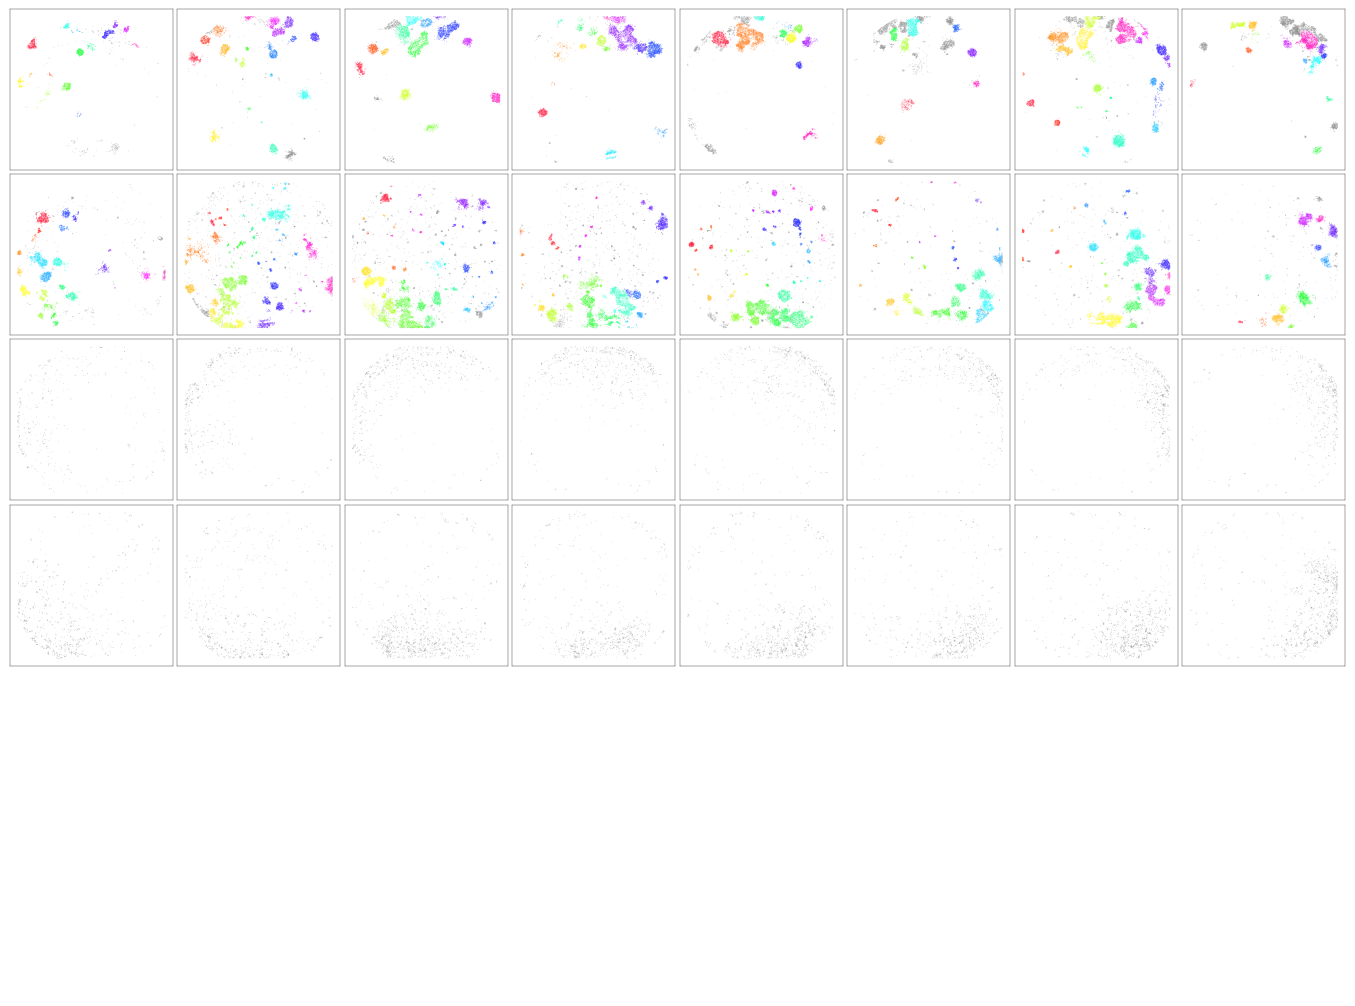

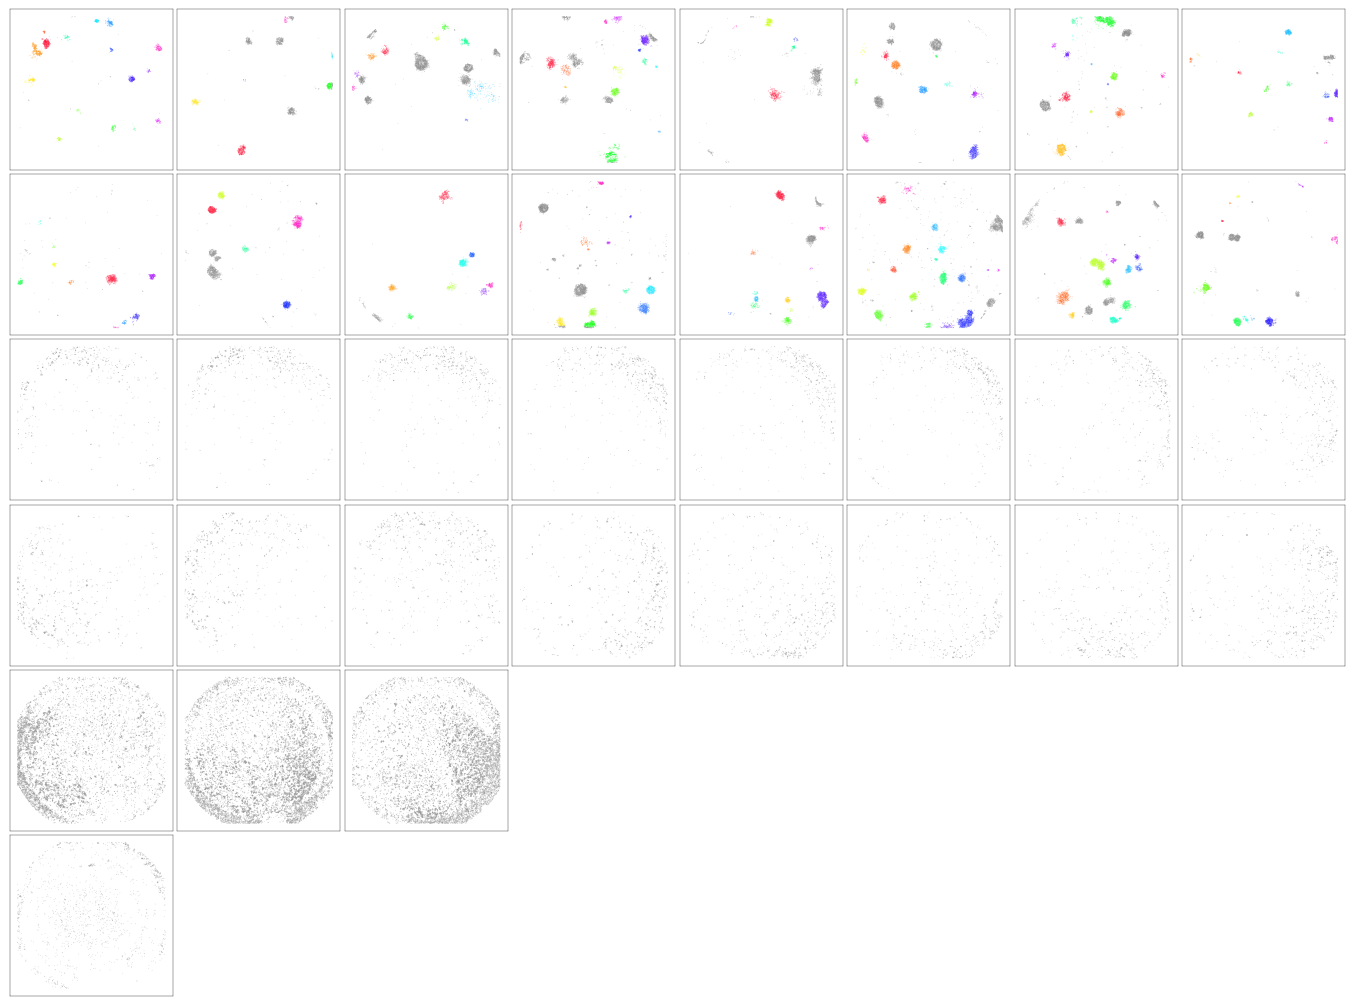

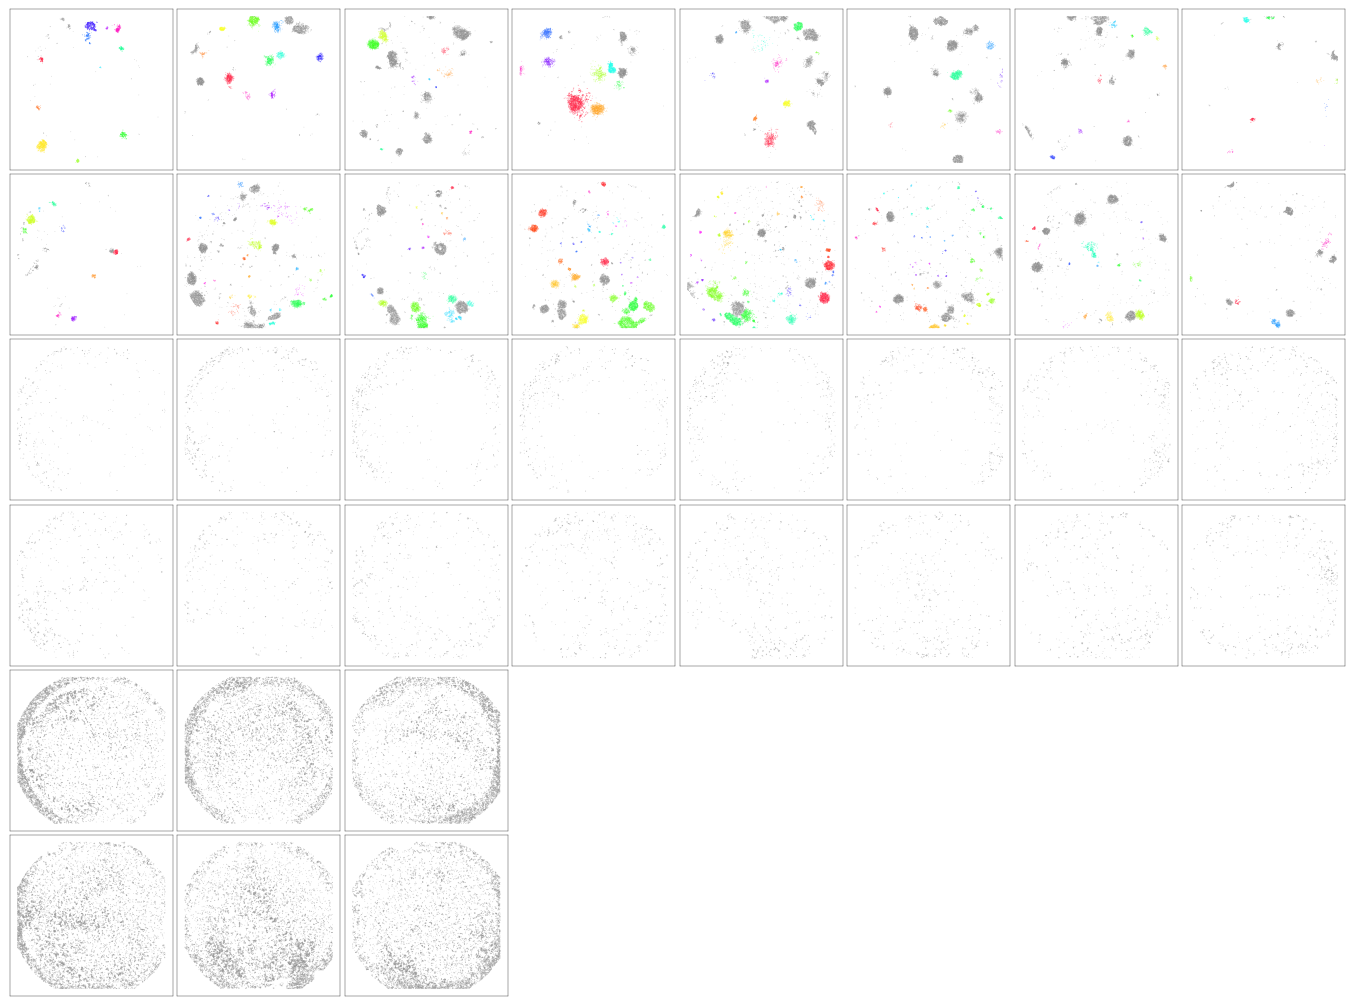

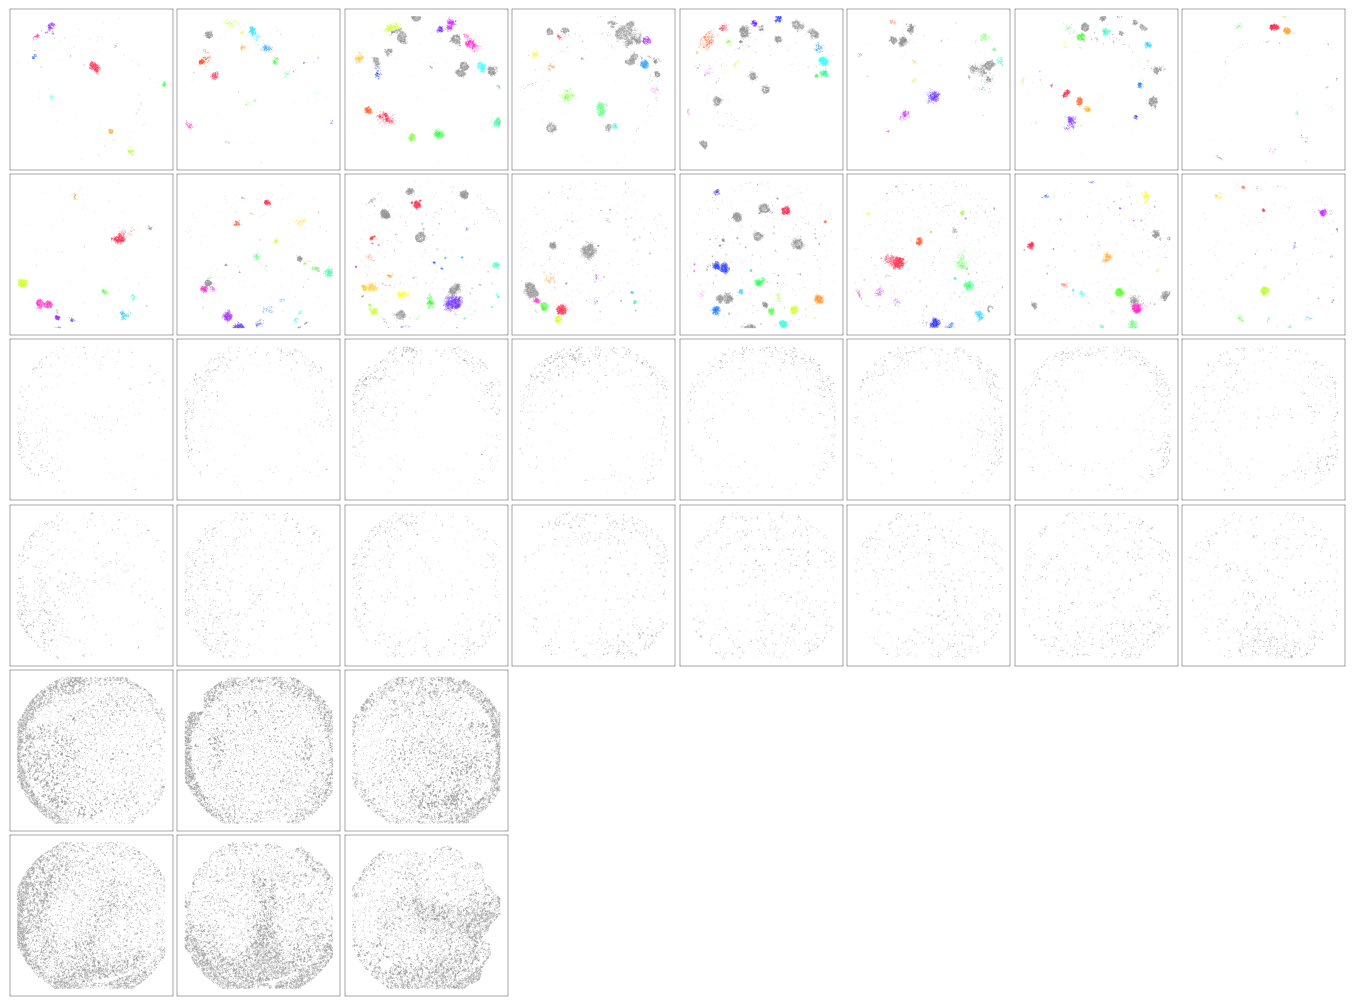

In [29]:
for plate in unique_plates:
    
    plate_clones_df = quant_df.loc[plate, :, :, :]
    plate_clones_well_ids = plate_clones_df.index.get_level_values('Well').unique().sort_values()
    
    fig, axes = plt.subplot_mosaic(fig_mosaic, **fig_opts)
    
    for _, ax in axes.items():
        ax.set_axis_off()
    
    for well in plate_clones_well_ids:
        ax = axes[well]
        ax.set_axis_on()
        for s in sides: ax.spines[s].set_linewidth(0.25)
        ax.set_xticks([]);  ax.set_yticks([])
        ax.set_xlabel('');  ax.set_ylabel('')
        #ax.annotate(text=f"{well}", **annot_opts)

        well_data = plate_clones_df.loc[well, :, :]
        clones_well_data    = well_data.loc[ well_data.index.get_level_values('Clone') >= 0, :]
        nonclones_well_data = well_data.loc[ well_data.index.get_level_values('Clone') <  0, :]
        
        x, y = nonclones_well_data[['nuc_center_x', 'nuc_center_y']].values.T
        ax.scatter(x, -y, c='gray', **scatter_opts)
        
        x, y = clones_well_data[['nuc_center_x', 'nuc_center_y']].values.T
        c = clones_well_data.index.get_level_values('Clone')
        ax.scatter(x, -y, c=c, cmap='gist_rainbow', **scatter_opts)

    #fig.suptitle(f"Plate {plate}: Overview of Clusters")
    fig.subplots_adjust(wspace=0.03, hspace=0.025, left=0.01, right=0.9, top=0.95, bottom=0.01)
    # fig.tight_layout(h_pad=-0.15, w_pad=-0.1);
    fig.savefig(f"Layout_ex_tnfr2_f480/plate_overview--expt--plate_{plate}.png", dpi=600);